# Maestría en Inteligencia Artificial — Aprendizaje Supervisado
## Análisis de Ventaja de Género en Educación Mundial (UNESCO)
### Pregunta de investigación: *¿El país favorece más a las mujeres o a los hombres en educación?*

---

| Elemento | Detalle |
|---|---|
| **Dataset** | `datos_educativos.csv` — Indicadores UNESCO globales |
| **Variable Objetivo** | `Ventaja_Genero`: 1 = Mujer favorecida (tasa femenina > masculina), 0 = Hombre favorecido |
| **Modelos** | Decision Tree · SVM · Random Forest · Logistic Regression · KNN · Naive Bayes · XGBoost · SVC (Linear) |
| **Cobertura** | 210 países · 2000-2022 · 3 niveles educativos |

---

## 1. Fundamentos: Clasificación vs. Regresión

Antes de entrenar cualquier modelo, es fundamental **formular el problema correctamente**.

| Dimensión | Clasificación ✅ (este proyecto) | Regresión |
|---|---|---|
| Variable objetivo | Categórica / discreta | Numérica / continua |
| Pregunta que responde | ¿El país favorece más a Mujeres o Hombres? | ¿Cuánto es la brecha de matrícula? |
| Métricas principales | Accuracy, F1, AUC-ROC | MAE, RMSE, R² |

**Elección: Clasificación Binaria.** La variable `Ventaja_Genero` toma únicamente dos valores (0/1), por lo que el problema es inherentemente de clasificación supervisada.

In [1]:
# ══════════════════════════════════════════════════════════════════
# 1. CARGA DE LIBRERÍAS Y DATOS
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, kstest, norm
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Estilo global de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# ── Carga del dataset ──
df_raw = pd.read_csv('datos_educativos.csv')
print(f"\nDimensiones originales: {df_raw.shape}")
print(f"Columnas: {df_raw.columns.tolist()}")
print(f"\nPrimeras filas:")
df_raw.head()

✓ XGBoost disponible

Dimensiones originales: (5765, 7)
Columnas: ['Índice', 'ID', 'Pais', 'Año', 'Tipo de Dato Educativo', 'Tasa', 'Fuente Datos']

Primeras filas:


,Índice,ID,Pais,Año,Tipo de Dato Educativo,Tasa,Fuente Datos
0,432,53,Australia and New Zealand,2005,Tasa Matrícula Primaria (Hombres),101.7,"""United Nations Educational, Scientific and Cu..."
1,433,53,Australia and New Zealand,2005,Tasa Matrícula Primaria (Mujeres),102.9,"""United Nations Educational, Scientific and Cu..."
2,435,53,Australia and New Zealand,2005,Tasa Matrícula Sec. Baja (Hombres),114.3,"""United Nations Educational, Scientific and Cu..."
3,436,53,Australia and New Zealand,2005,Tasa Matrícula Sec. Baja (Mujeres),116.2,"""United Nations Educational, Scientific and Cu..."
4,438,53,Australia and New Zealand,2005,Tasa Matrícula Sec. Alta (Hombres),212.6,"""United Nations Educational, Scientific and Cu..."


---
## 2. Análisis Exploratorio de Datos (EDA)
### 2.1 Construcción del Dataset y Variable Objetivo `Ventaja_Genero`

La variable objetivo **`Ventaja_Genero`** responde a la pregunta de investigación:
- Se construye **por país, año y nivel educativo**
- Si la tasa de matrícula femenina > masculina → `Ventaja_Genero = 1` (Mujer favorecida)
- En caso contrario → `Ventaja_Genero = 0` (Hombre favorecido)

In [2]:
# ── Filtrar registros de género ──
df_gen = df_raw[df_raw['Tipo de Dato Educativo'].str.contains(
    r'\(Mujeres\)|\(Hombres\)', na=False)].copy()

# ── Extraer nivel educativo y género ──
def get_nivel(txt):
    if 'Primaria'  in txt: return 'Primaria'
    if 'Sec. Baja' in txt: return 'Sec_Baja'
    if 'Sec. Alta' in txt: return 'Sec_Alta'
    return 'Otro'

def get_genero(txt):
    return 'Mujeres' if '(Mujeres)' in txt else 'Hombres'

df_gen['Nivel']  = df_gen['Tipo de Dato Educativo'].apply(get_nivel)
df_gen['Genero'] = df_gen['Tipo de Dato Educativo'].apply(get_genero)

# ── Pivotear: una fila por (País, Año, Nivel) con columnas Mujeres/Hombres ──
pivot = df_gen.pivot_table(
    index=['Pais', 'Año', 'Nivel'],
    columns='Genero',
    values='Tasa'
).reset_index()
pivot.columns.name = None
pivot = pivot.dropna(subset=['Mujeres', 'Hombres'])

# ── Crear variable objetivo ──
pivot['Ventaja_Genero'] = (pivot['Mujeres'] > pivot['Hombres']).astype(int)

# ── Brecha absoluta (feature adicional) ──
pivot['Brecha'] = pivot['Mujeres'] - pivot['Hombres']

# Dataset de trabajo
df = pivot.copy()

print(f"{'='*55}")
print(f"  DATASET CONSTRUIDO PARA MODELADO")
print(f"{'='*55}")
print(f"  Filas totales       : {df.shape[0]}")
print(f"  Países únicos       : {df['Pais'].nunique()}")
print(f"  Rango de años       : {df['Año'].min()} – {df['Año'].max()}")
print(f"  Niveles educativos  : {df['Nivel'].unique().tolist()}")
print(f"{'='*55}")
print(f"\n  DISTRIBUCIÓN DE LA VARIABLE OBJETIVO:")
vc = df['Ventaja_Genero'].value_counts()
print(f"  Hombre favorecido (0): {vc[0]:>5}  ({vc[0]/len(df)*100:.1f}%)")
print(f"  Mujer  favorecida (1): {vc[1]:>5}  ({vc[1]/len(df)*100:.1f}%)")
print(f"\nPrimeras filas del dataset:")
df[['Pais','Año','Nivel','Hombres','Mujeres','Brecha','Ventaja_Genero']].head(8)

  DATASET CONSTRUIDO PARA MODELADO
  Filas totales       : 2281
  Países únicos       : 208
  Rango de años       : 2000 – 2022
  Niveles educativos  : ['Sec_Alta', 'Sec_Baja', 'Primaria']

  DISTRIBUCIÓN DE LA VARIABLE OBJETIVO:
  Hombre favorecido (0):  1332  (58.4%)
  Mujer  favorecida (1):   949  (41.6%)

Primeras filas del dataset:


,Pais,Año,Nivel,Hombres,Mujeres,Brecha,Ventaja_Genero
0,"""China, Hong Kong SAR""",2005,Sec_Alta,68.5,70.5,2.0,1
1,"""China, Hong Kong SAR""",2005,Sec_Baja,99.8,99.3,-0.5,0
2,"""China, Hong Kong SAR""",2010,Sec_Alta,76.4,77.7,1.3,1
3,"""China, Hong Kong SAR""",2010,Sec_Baja,105.1,104.1,-1.0,0
4,"""China, Hong Kong SAR""",2015,Primaria,109.3,111.2,1.9,1
5,"""China, Hong Kong SAR""",2015,Sec_Alta,99.2,97.9,-1.3,0
6,"""China, Hong Kong SAR""",2015,Sec_Baja,107.9,105.6,-2.3,0
7,"""China, Hong Kong SAR""",2021,Primaria,101.6,106.0,4.4,1


### 2.2 Información General del Dataset

In [3]:
print("── Tipos de datos ──")
print(df[['Pais','Año','Nivel','Hombres','Mujeres','Brecha','Ventaja_Genero']].dtypes)
print("\n── Valores nulos ──")
print(df[['Pais','Año','Nivel','Hombres','Mujeres','Brecha','Ventaja_Genero']].isnull().sum())
print(f"\n── Países únicos  : {df['Pais'].nunique()}")
print(f"── Años disponibles: {sorted(df['Año'].unique().tolist())}")
print(f"\n── Estadística rápida — Variable Brecha (Mujeres - Hombres):")
print(df['Brecha'].describe().round(3))

── Tipos de datos ──
Pais               object
Año                 int64
Nivel              object
Hombres           float64
Mujeres           float64
Brecha            float64
Ventaja_Genero      int64
dtype: object

── Valores nulos ──
Pais              0
Año               0
Nivel             0
Hombres           0
Mujeres           0
Brecha            0
Ventaja_Genero    0
dtype: int64

── Países únicos  : 208
── Años disponibles: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

── Estadística rápida — Variable Brecha (Mujeres - Hombres):
count    2281.000
mean       -0.804
std         9.139
min       -68.000
25%        -4.200
50%        -0.600
75%         2.400
max        60.900
Name: Brecha, dtype: float64


### 2.3 Estadística Descriptiva: Medidas de Tendencia Central, Dispersión y Posición

Se analizan las variables numéricas clave: `Mujeres`, `Hombres` y `Brecha` (diferencia de tasas),tanto de forma global como desagregada por **nivel educativo** y **ventaja de género**.

In [9]:
def resumen_estadistico(serie, nombre):
    """Calcula un resumen estadístico completo de una Serie."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    return {
        'Variable': nombre,
        'N': len(serie),
        'Media': round(serie.mean(), 3),
        'Mediana': round(serie.median(), 3),
        'Moda': round(serie.mode()[0], 3),
        'Desv. Est.': round(serie.std(), 3),
        'Varianza': round(serie.var(), 3),
        'CV (%)': round(serie.std()/serie.mean()*100, 2),
        'IQR': round(q3 - q1, 3),
        'Rango': round(serie.max() - serie.min(), 3),
        'P10': round(serie.quantile(0.10), 3),
        'P25 (Q1)': round(q1, 3),
        'P50 (Med)': round(serie.quantile(0.50), 3),
        'P75 (Q3)': round(q3, 3),
        'P90': round(serie.quantile(0.90), 3),
        'Mínimo': round(serie.min(), 3),
        'Máximo': round(serie.max(), 3),
        'Sesgo': round(serie.skew(), 3),
        'Curtosis': round(serie.kurt(), 3),
    }

# ── Tabla global ──
variables = {'Tasa Mujeres': df['Mujeres'], 'Tasa Hombres': df['Hombres'], 'Brecha (M-H)': df['Brecha']}
tabla_global = pd.DataFrame([resumen_estadistico(v, k) for k, v in variables.items()])

print("="*70)
print("  RESUMEN ESTADÍSTICO GLOBAL")
print("="*70)
print(tabla_global.set_index('Variable').T.to_string())

# ── Por ventaja de género ──
tabla_vg = df.groupby('Ventaja_Genero')[['Mujeres','Hombres','Brecha']].agg(
    ['count', 'mean', 'median', 'std']
).round(2)

tabla_vg.columns = ['_'.join(c) for c in tabla_vg.columns]
tabla_vg.index = tabla_vg.index.map({0: 'Hombre favorecido (0)', 1: 'Mujer favorecida (1)'})

# Renombrar columnas para que se vean limpias
tabla_vg.columns = [
    'Mujeres_N', 'Mujeres_Media', 'Mujeres_Mediana', 'Mujeres_Desv',
    'Hombres_N', 'Hombres_Media', 'Hombres_Mediana', 'Hombres_Desv',
    'Brecha_N',  'Brecha_Media',  'Brecha_Mediana',  'Brecha_Desv'
]

# Transponer para leer mejor (variables como filas, estadísticos como columnas)
tabla_vg_T = tabla_vg.T
tabla_vg_T.index = pd.MultiIndex.from_tuples(
    [col.split('_', 1) for col in tabla_vg_T.index],
    names=['Variable', 'Estadístico']
)

print("=" * 62)
print("  ESTADÍSTICOS POR VENTAJA DE GÉNERO (0=Hombre, 1=Mujer)")
print("=" * 62)
print(tabla_vg_T.to_string())

  RESUMEN ESTADÍSTICO GLOBAL
Variable    Tasa Mujeres  Tasa Hombres  Brecha (M-H)
N               2281.000      2281.000      2281.000
Media             89.681        90.485        -0.804
Mediana           97.900        98.600        -0.600
Moda             100.200        99.800         0.000
Desv. Est.        29.697        28.763         9.139
Varianza         881.907       827.325        83.528
CV (%)            33.110        31.790     -1136.750
IQR               27.200        29.600         6.600
Rango            207.300       238.900       128.900
P10               42.200        46.900        -9.700
P25 (Q1)          78.200        77.000        -4.200
P50 (Med)         97.900        98.600        -0.600
P75 (Q3)         105.400       106.600         2.400
P90              114.900       117.300         9.200
Mínimo             2.900         5.300       -68.000
Máximo           210.200       244.200        60.900
Sesgo             -0.705        -0.477        -0.485
Curtosis         

### 2.4 Diagnóstico de Datos Atípicos — Boxplots

Los boxplots identifican visualmente los **valores atípicos** mediante el criterio IQR:  
**Límite inferior** = Q1 − 1.5×IQR  ·  **Límite superior** = Q3 + 1.5×IQR  
Los puntos fuera de estos límites se consideran *outliers* (marcados en rojo).

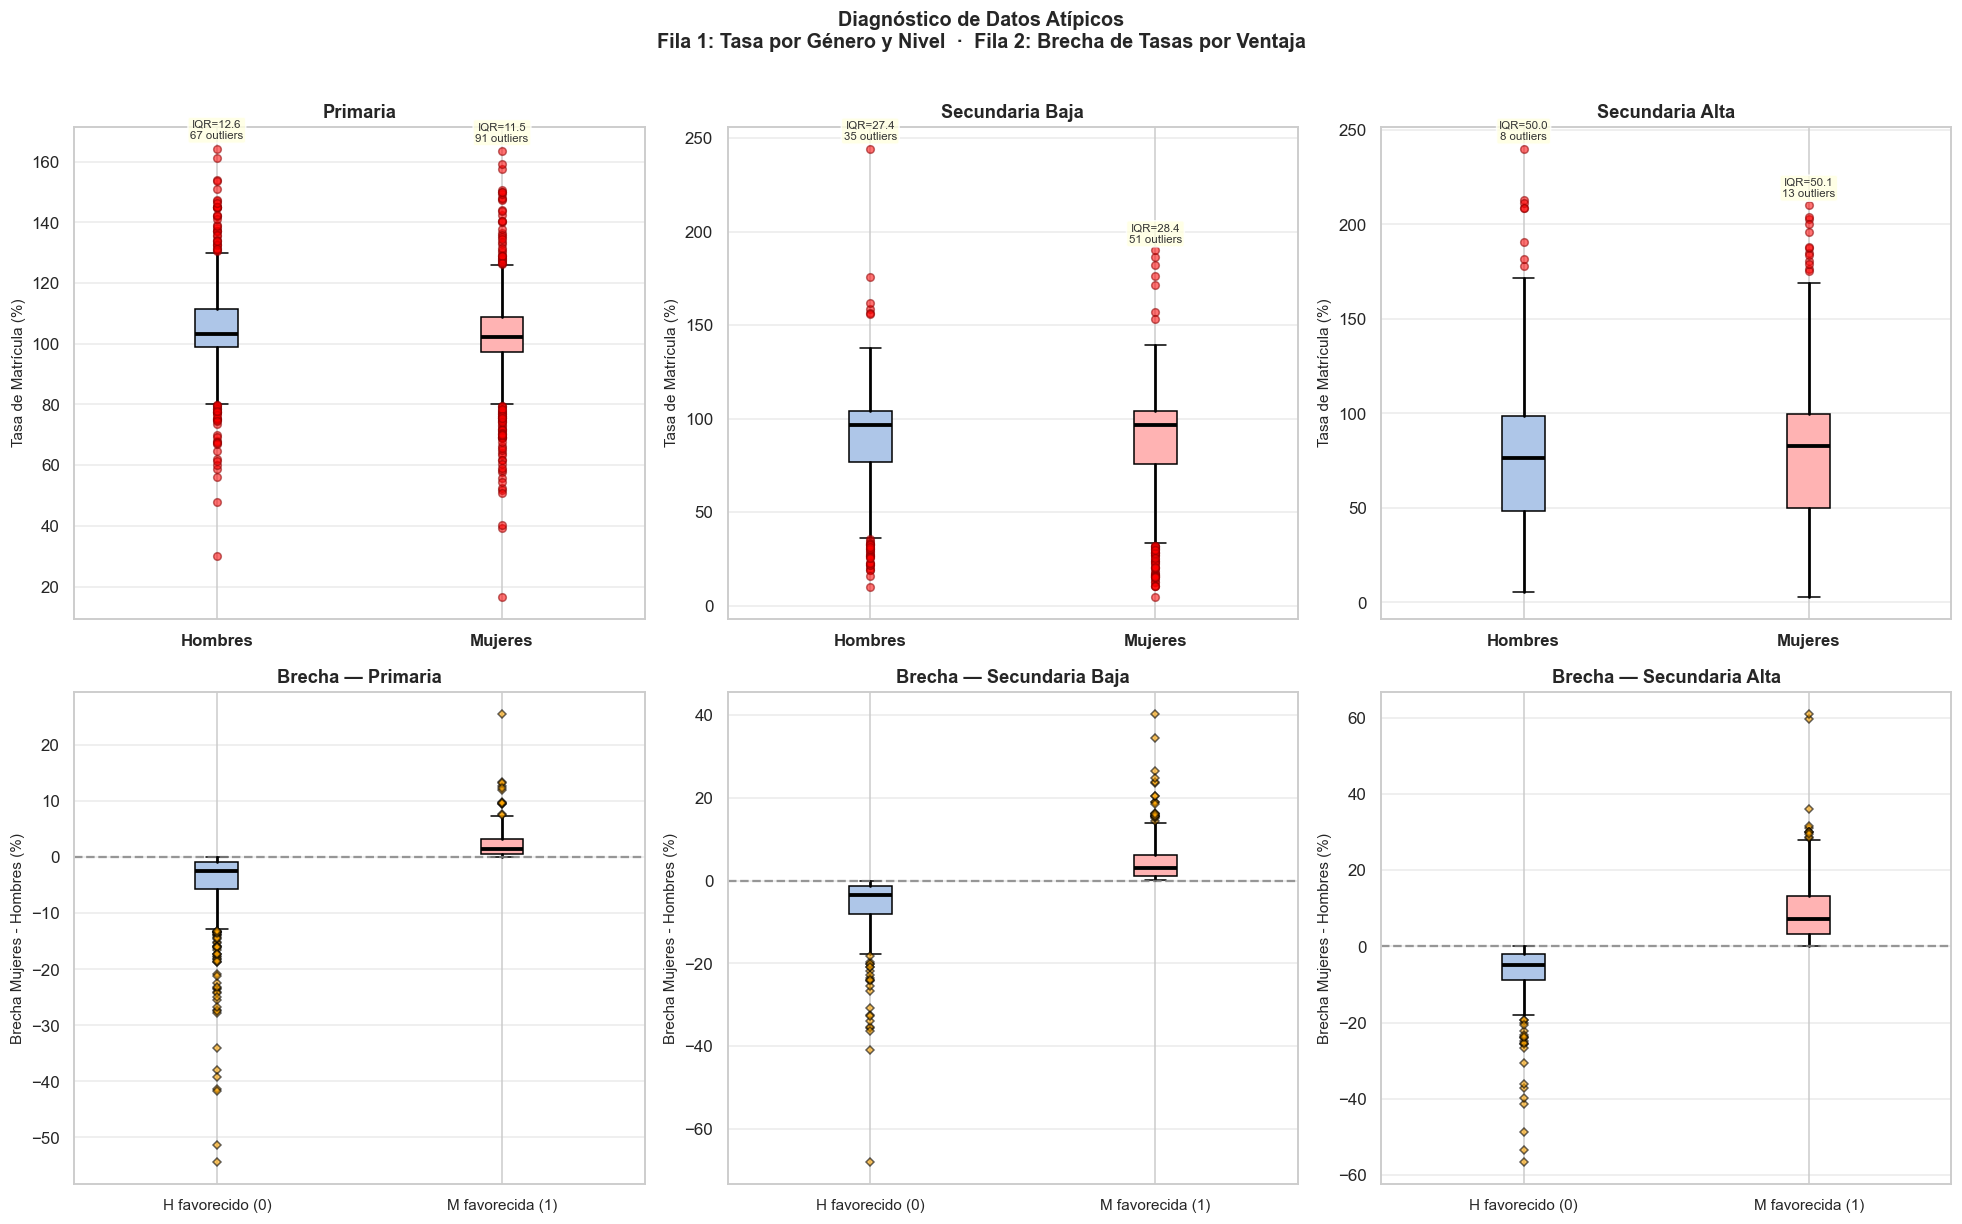


── RESUMEN CUANTITATIVO DE OUTLIERS (Método IQR) ──
Nivel        Variable         N Outliers  % Outliers
----------------------------------------------------
Primaria     Hombres        816       67        8.2%
Primaria     Mujeres        816       91       11.2%
Primaria     Brecha         816       87       10.7%
Sec_Baja     Hombres        767       35        4.6%
Sec_Baja     Mujeres        767       51        6.6%
Sec_Baja     Brecha         767       73        9.5%
Sec_Alta     Hombres        698        8        1.1%
Sec_Alta     Mujeres        698       13        1.9%
Sec_Alta     Brecha         698       29        4.2%


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
niveles_labels = ['Primaria', 'Sec_Baja', 'Sec_Alta']
niveles_display = ['Primaria', 'Secundaria Baja', 'Secundaria Alta']
colores_gen = {'Hombres': '#4C72B0', 'Mujeres': '#DD6B6B'}

# ── Fila 1: Tasa por género y nivel ──
for j, (nv, nv_disp) in enumerate(zip(niveles_labels, niveles_display)):
    ax = axes[0, j]
    sub = df[df['Nivel'] == nv]
    datos = [sub['Hombres'].dropna(), sub['Mujeres'].dropna()]
    bp = ax.boxplot(datos, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.8),
                    flierprops=dict(marker='o', markerfacecolor='red',
                                   markersize=5, alpha=0.55, markeredgecolor='darkred'))
    bp['boxes'][0].set_facecolor('#AEC6E8')
    bp['boxes'][1].set_facecolor('#FFB3B3')
    ax.set_xticklabels(['Hombres', 'Mujeres'], fontsize=11, fontweight='bold')
    ax.set_title(f'{nv_disp}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Tasa de Matrícula (%)', fontsize=10)
    ax.grid(axis='y', alpha=0.4)
    
    # Anotar IQR y outliers
    for k, datos_gen in enumerate(datos):
        q1_, q3_ = datos_gen.quantile(0.25), datos_gen.quantile(0.75)
        iqr_ = q3_ - q1_
        n_out = ((datos_gen < q1_ - 1.5*iqr_) | (datos_gen > q3_ + 1.5*iqr_)).sum()
        ax.text(k+1, datos_gen.max()*1.02, f'IQR={iqr_:.1f}\n{n_out} outliers',
                ha='center', fontsize=7.5, color='#333333',
                bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))

# ── Fila 2: Brecha (Mujeres - Hombres) por nivel, separado por Ventaja_Genero ──
for j, (nv, nv_disp) in enumerate(zip(niveles_labels, niveles_display)):
    ax = axes[1, j]
    sub = df[df['Nivel'] == nv]
    
    datos_h = sub[sub['Ventaja_Genero'] == 0]['Brecha'].dropna()
    datos_m = sub[sub['Ventaja_Genero'] == 1]['Brecha'].dropna()
    
    bp2 = ax.boxplot([datos_h, datos_m], patch_artist=True, notch=False,
                     medianprops=dict(color='black', linewidth=2.5),
                     whiskerprops=dict(linewidth=1.8),
                     flierprops=dict(marker='D', markerfacecolor='orange',
                                    markersize=4, alpha=0.6))
    bp2['boxes'][0].set_facecolor('#AEC6E8')
    bp2['boxes'][1].set_facecolor('#FFB3B3')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.set_xticklabels(['H favorecido (0)', 'M favorecida (1)'], fontsize=10)
    ax.set_title(f'Brecha — {nv_disp}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Brecha Mujeres - Hombres (%)', fontsize=10)
    ax.grid(axis='y', alpha=0.4)

fig.suptitle('Diagnóstico de Datos Atípicos\nFila 1: Tasa por Género y Nivel  ·  Fila 2: Brecha de Tasas por Ventaja',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots_atipicos.png', bbox_inches='tight', dpi=130)
plt.show()

# ── Resumen cuantitativo de outliers ──
print("\n── RESUMEN CUANTITATIVO DE OUTLIERS (Método IQR) ──")
print(f"{'Nivel':<12} {'Variable':<12} {'N':>5} {'Outliers':>8} {'% Outliers':>11}")
print("-" * 52)
for nv in niveles_labels:
    for var in ['Hombres', 'Mujeres', 'Brecha']:
        serie = df[df['Nivel'] == nv][var].dropna()
        q1_, q3_ = serie.quantile(0.25), serie.quantile(0.75)
        iqr_ = q3_ - q1_
        n_out = ((serie < q1_ - 1.5*iqr_) | (serie > q3_ + 1.5*iqr_)).sum()
        print(f"{nv:<12} {var:<12} {len(serie):>5} {n_out:>8} {n_out/len(serie)*100:>10.1f}%")

### 2.5 Análisis de Distribución y Normalidad
#### 2.5.1 Histogramas con Curva KDE y Distribución Normal Teórica

La **KDE (Kernel Density Estimation)** es una estimación suavizada de la densidad de probabilidad  
que permite visualizar la forma real de la distribución sin los artefactos del binning del histograma.

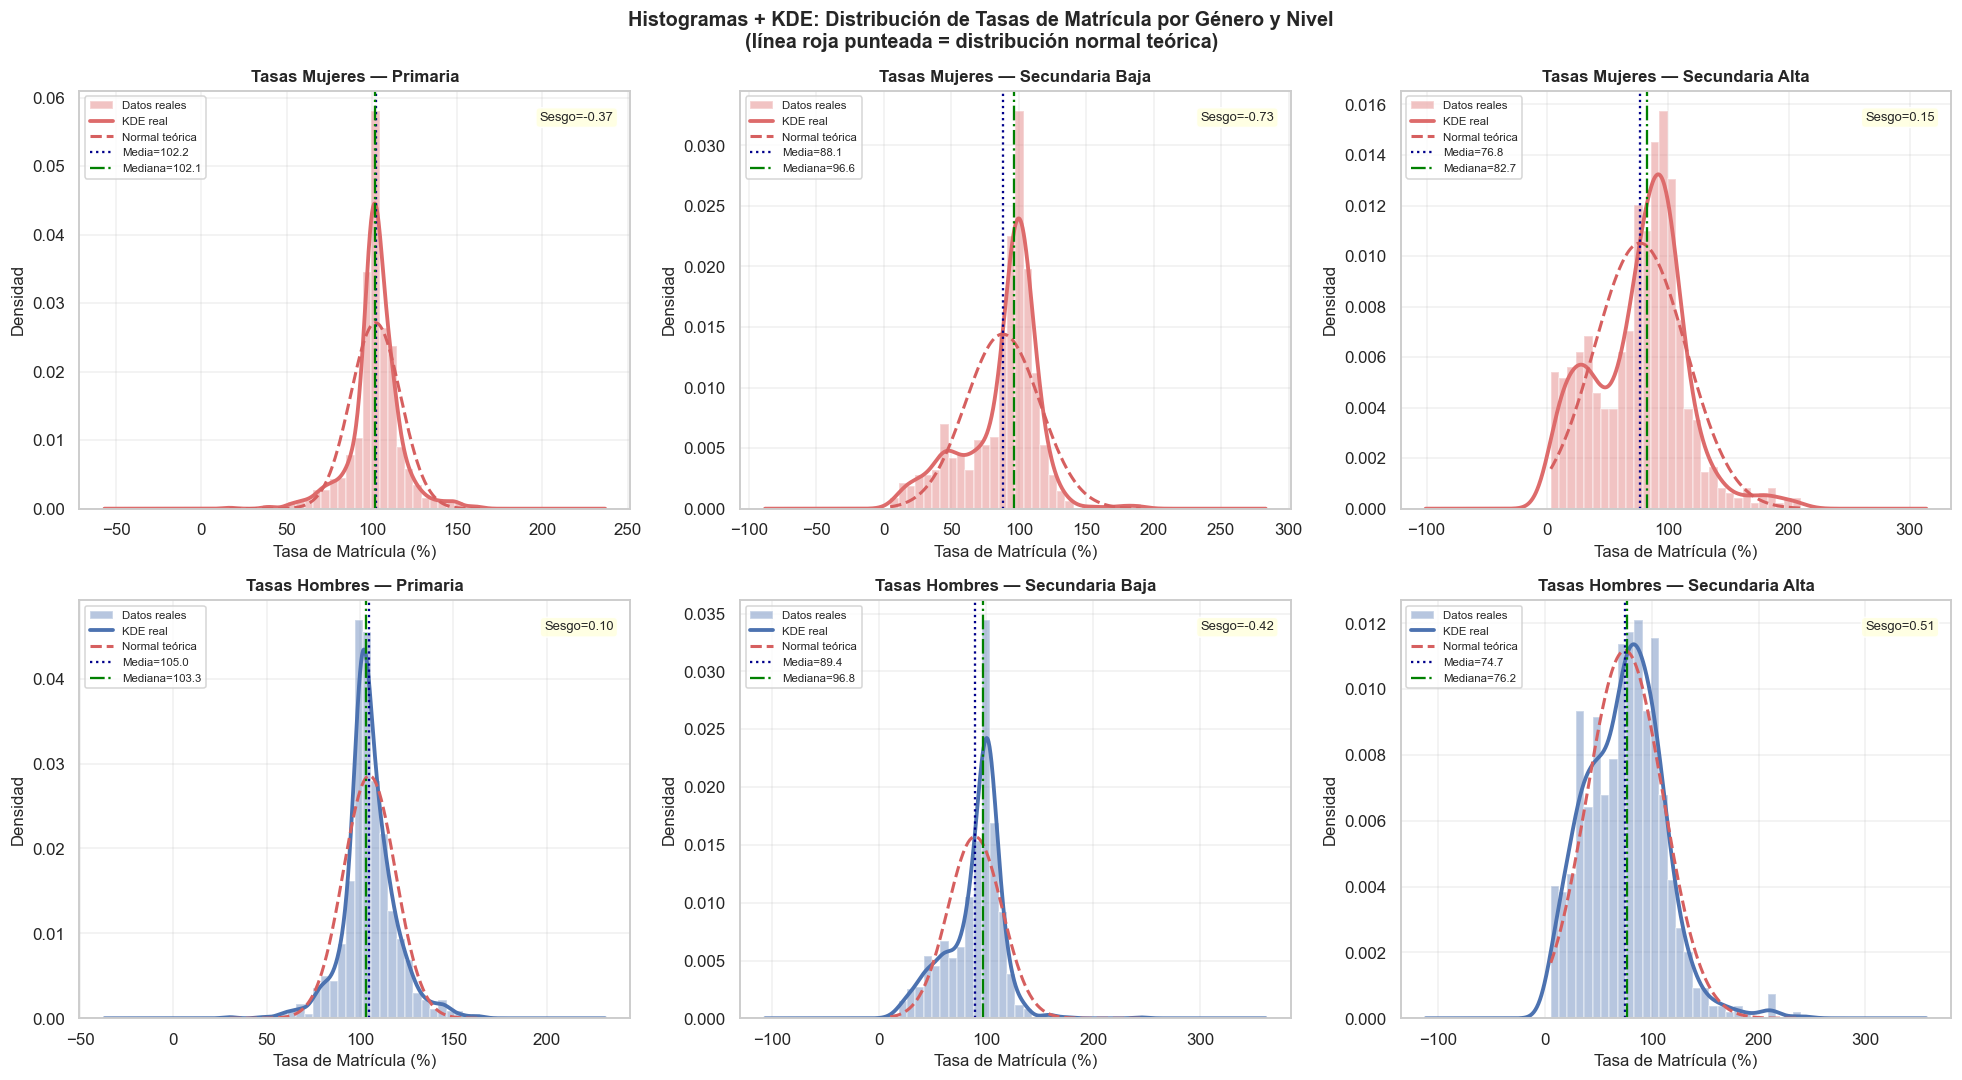

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
niveles_labels = ['Primaria', 'Sec_Baja', 'Sec_Alta']
niveles_display = ['Primaria', 'Secundaria Baja', 'Secundaria Alta']

variables_hist = {
    0: ('Mujeres', '#DD6B6B', 'Tasas Mujeres'),
    1: ('Hombres', '#4C72B0', 'Tasas Hombres'),
}

for col_idx, (var, color, label) in variables_hist.items():
    for row_idx, (nv, nv_disp) in enumerate(zip(niveles_labels, niveles_display)):
        # Asignar ejes: fila 0 = Mujeres, fila 1 = Hombres
        ax = axes[col_idx, row_idx]
        datos = df[df['Nivel'] == nv][var].dropna()
        mu, sigma = datos.mean(), datos.std()
        
        # Histograma
        ax.hist(datos, bins=30, density=True, alpha=0.40, color=color,
                edgecolor='white', label='Datos reales')
        # KDE real
        datos.plot.kde(ax=ax, color=color, linewidth=2.5, label='KDE real')
        # Normal teórica
        x = np.linspace(datos.min(), datos.max(), 300)
        ax.plot(x, norm.pdf(x, mu, sigma), 'r--', linewidth=2, label='Normal teórica')
        # Líneas de posición
        ax.axvline(mu, color='darkblue', linestyle=':', linewidth=1.5, label=f'Media={mu:.1f}')
        ax.axvline(datos.median(), color='green', linestyle='-.', linewidth=1.5,
                   label=f'Mediana={datos.median():.1f}')
        
        # Anotación de sesgo
        skew = datos.skew()
        ax.text(0.97, 0.95, f'Sesgo={skew:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))
        
        ax.set_title(f'{label} — {nv_disp}', fontweight='bold', fontsize=11)
        ax.set_xlabel('Tasa de Matrícula (%)')
        ax.set_ylabel('Densidad')
        ax.legend(fontsize=7.5)
        ax.grid(alpha=0.3)

fig.suptitle('Histogramas + KDE: Distribución de Tasas de Matrícula por Género y Nivel\n'
             '(línea roja punteada = distribución normal teórica)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('histogramas_kde.png', bbox_inches='tight', dpi=130)
plt.show()

#### 2.5.2 Gráficos QQ-Plot (Quantile-Quantile)

El QQ-Plot compara los cuantiles observados vs. los cuantiles de una distribución normal teórica.  
**Interpretación:** Si los puntos se alinean sobre la línea roja → los datos son aproximadamente normales.

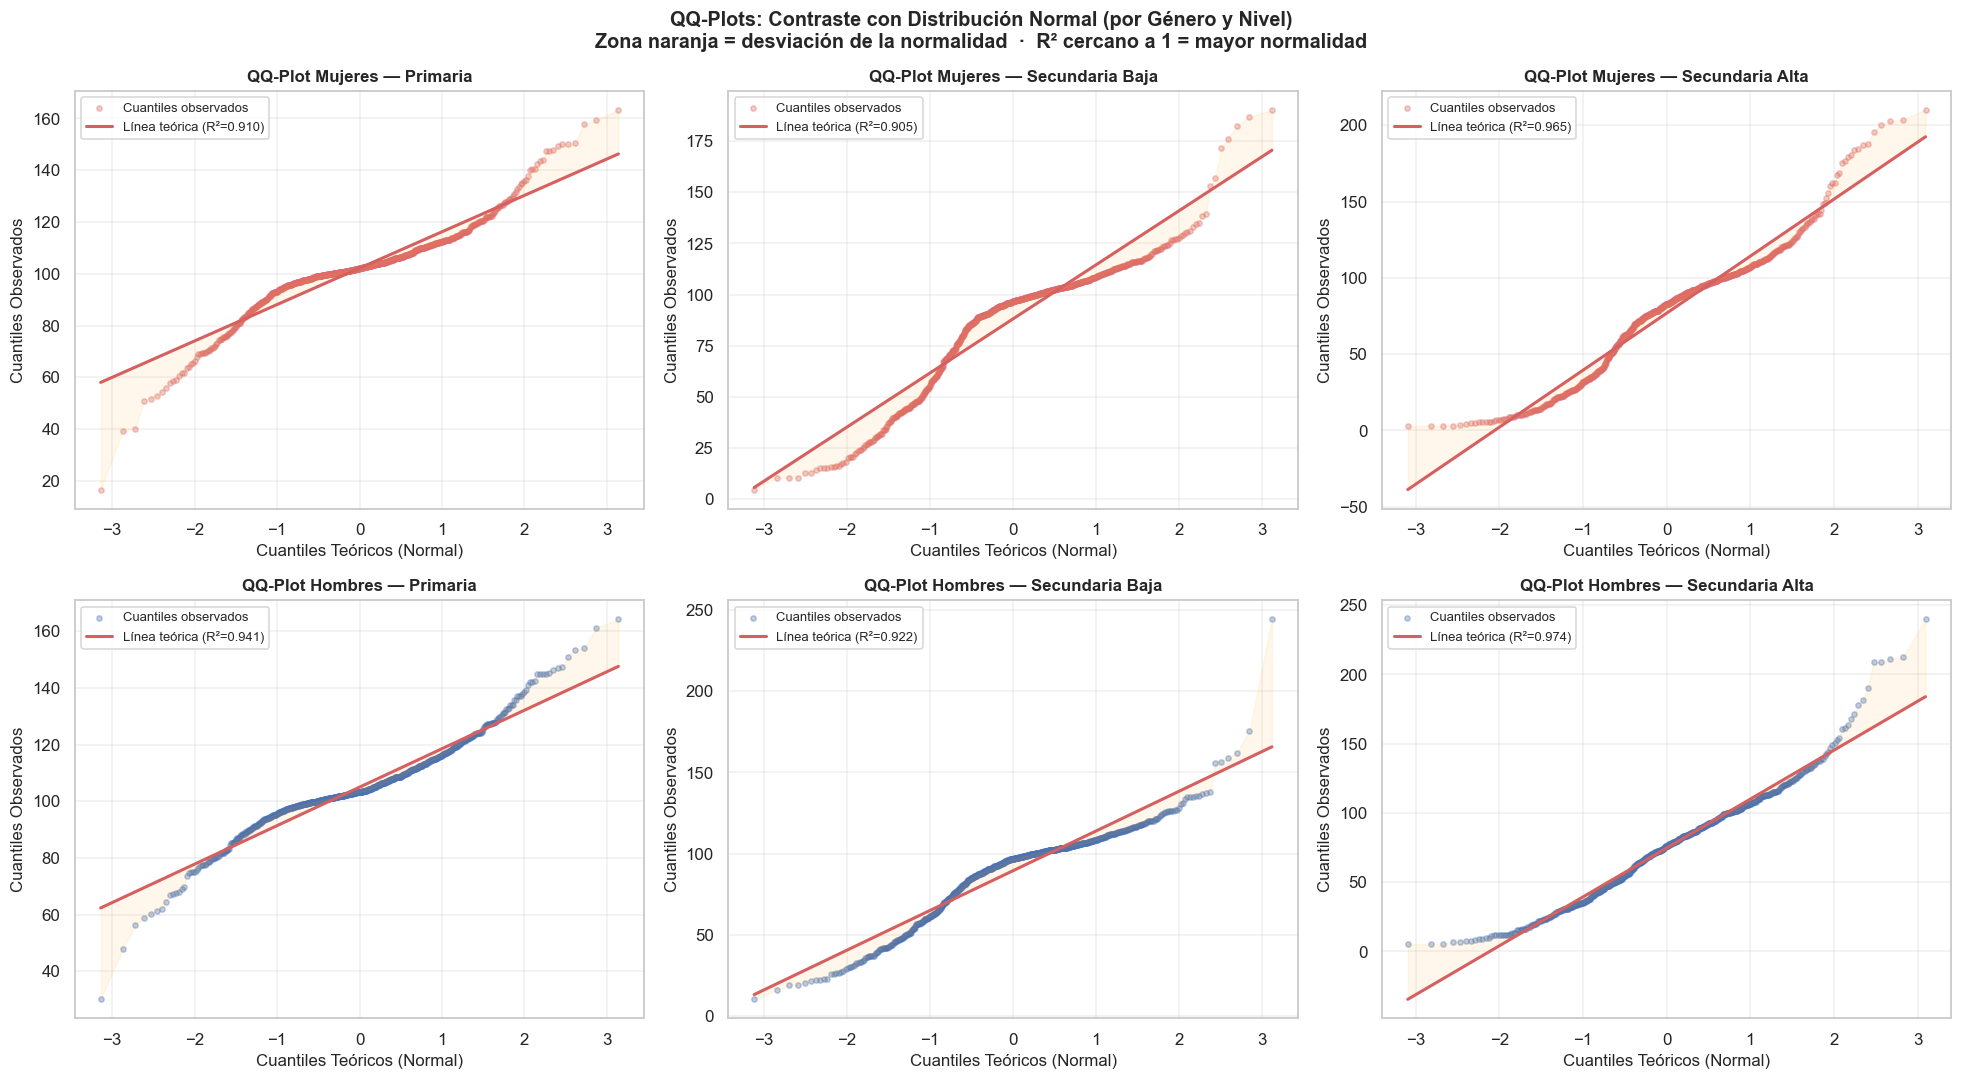

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, var in enumerate(['Mujeres', 'Hombres']):
    for row_idx, (nv, nv_disp) in enumerate(zip(niveles_labels, niveles_display)):
        ax = axes[col_idx, row_idx]
        datos = df[df['Nivel'] == nv][var].dropna()
        
        (osm, osr), (slope, intercept, r) = stats.probplot(datos, dist='norm')
        
        ax.scatter(osm, osr, alpha=0.35, s=12, 
                   color='#DD6B6B' if var == 'Mujeres' else '#4C72B0',
                   label='Cuantiles observados')
        ax.plot(osm, slope*np.array(osm) + intercept, 'r-', linewidth=2,
                label=f'Línea teórica (R²={r**2:.3f})')
        
        # Colorear zonas de desviación
        ax.fill_between(osm, osr, slope*np.array(osm) + intercept,
                        alpha=0.08, color='orange')
        
        ax.set_title(f'QQ-Plot {var} — {nv_disp}', fontweight='bold', fontsize=11)
        ax.set_xlabel('Cuantiles Teóricos (Normal)')
        ax.set_ylabel('Cuantiles Observados')
        ax.legend(fontsize=8.5)
        ax.grid(alpha=0.3)

fig.suptitle('QQ-Plots: Contraste con Distribución Normal (por Género y Nivel)\n'
             'Zona naranja = desviación de la normalidad  ·  R² cercano a 1 = mayor normalidad',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('qqplots.png', bbox_inches='tight', dpi=130)
plt.show()

#### 2.5.3 Pruebas Estadísticas de Normalidad

- **Shapiro-Wilk (SW):** Recomendada para n < 5,000. H₀: los datos siguen distribución normal.  
- **Kolmogorov-Smirnov (KS):** Contraste contra distribución normal estandarizada; válida para muestras grandes.  
- **Criterio de decisión:** si p-valor < 0.05 → se rechaza H₀ → los datos **NO son normales**.

In [13]:
np.random.seed(42)
resultados_norm = []

for nv in niveles_labels:
    for var in ['Mujeres', 'Hombres', 'Brecha']:
        datos = df[df['Nivel'] == nv][var].dropna()
        
        # Shapiro-Wilk (muestra máx 5000)
        muestra_sw = datos.sample(min(len(datos), 1000), random_state=42)
        stat_sw, p_sw = shapiro(muestra_sw)
        
        # Kolmogorov-Smirnov (datos estandarizados)
        datos_std = (datos - datos.mean()) / datos.std()
        stat_ks, p_ks = kstest(datos_std, 'norm')
        
        resultados_norm.append({
            'Nivel':       nv,
            'Variable':    var,
            'N':           len(datos),
            'SW Estad.':   round(stat_sw, 4),
            'SW p-valor':  round(p_sw, 6),
            'SW Resultado':'✅ Normal' if p_sw >= 0.05 else '❌ No Normal',
            'KS Estad.':   round(stat_ks, 4),
            'KS p-valor':  round(p_ks, 6),
            'KS Resultado':'✅ Normal' if p_ks >= 0.05 else '❌ No Normal',
        })

df_norm = pd.DataFrame(resultados_norm)
print("="*90)
print("  RESULTADOS COMPLETOS DE PRUEBAS DE NORMALIDAD")
print("="*90)
print(df_norm.to_string(index=False))
print()
print("📌 Interpretación: p-valor < 0.05 → Se rechaza H₀ → Los datos NO siguen distribución normal")
print("   Implicación: Se justifica el uso de modelos robustos a no-normalidad (Random Forest, XGBoost)")

  RESULTADOS COMPLETOS DE PRUEBAS DE NORMALIDAD
   Nivel Variable   N  SW Estad.  SW p-valor SW Resultado  KS Estad.  KS p-valor KS Resultado
Primaria  Mujeres 816     0.9131         0.0  ❌ No Normal     0.1347    0.000000  ❌ No Normal
Primaria  Hombres 816     0.9437         0.0  ❌ No Normal     0.1013    0.000000  ❌ No Normal
Primaria   Brecha 816     0.7708         0.0  ❌ No Normal     0.1816    0.000000  ❌ No Normal
Sec_Baja  Mujeres 767     0.9057         0.0  ❌ No Normal     0.1753    0.000000  ❌ No Normal
Sec_Baja  Hombres 767     0.9244         0.0  ❌ No Normal     0.1328    0.000000  ❌ No Normal
Sec_Baja   Brecha 767     0.8891         0.0  ❌ No Normal     0.1148    0.000000  ❌ No Normal
Sec_Alta  Mujeres 698     0.9642         0.0  ❌ No Normal     0.0798    0.000257  ❌ No Normal
Sec_Alta  Hombres 698     0.9744         0.0  ❌ No Normal     0.0325    0.442089     ✅ Normal
Sec_Alta   Brecha 698     0.9442         0.0  ❌ No Normal     0.0778    0.000403  ❌ No Normal

📌 Interpret

### 2.6 Análisis de Correlación y Mapa de Ventaja por País

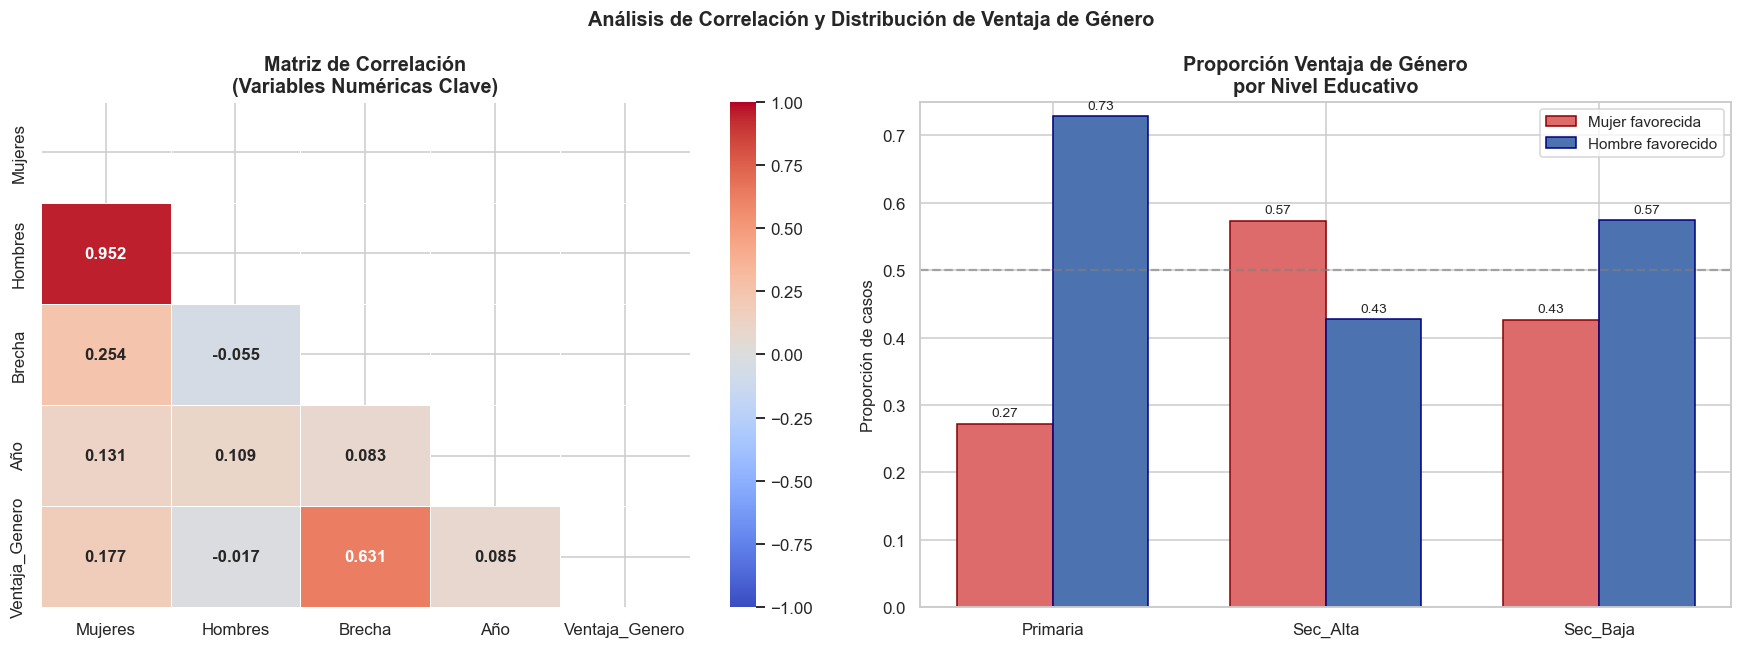


── Top 15 países con mayor proporción de ventaja femenina ──
       Pais  Prop_Mujer_Favorecida  N_Observaciones
Puerto Rico                  100.0                6
 Montenegro                  100.0               12
      Japan                  100.0                6
    Georgia                   93.8               16
   Kiribati                   92.3               13
   Malaysia                   91.7               12
     Israel                   91.7               12
    Jamaica                   88.9                9
     Gambia                   83.3               12
    Bermuda                   83.3               12
    Croatia                   83.3               12
    Ecuador                   83.3               12
 Seychelles                   83.3               12
    Bahrain                   78.6               14
 Bangladesh                   78.6               14


In [14]:
# ── Matriz de correlación ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlación entre variables numéricas
vars_corr = df[['Mujeres','Hombres','Brecha','Año','Ventaja_Genero']]
corr = vars_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=axes[0], linewidths=0.5,
            annot_kws={'size': 11, 'fontweight': 'bold'},
            vmin=-1, vmax=1)
axes[0].set_title('Matriz de Correlación\n(Variables Numéricas Clave)', fontweight='bold')

# ── Proporción de ventaja por nivel educativo ──
prop_nivel = df.groupby('Nivel')['Ventaja_Genero'].mean().reset_index()
prop_nivel.columns = ['Nivel', 'Proporcion_Mujer']
prop_nivel['Proporcion_Hombre'] = 1 - prop_nivel['Proporcion_Mujer']

x = np.arange(len(prop_nivel))
w = 0.35
axes[1].bar(x - w/2, prop_nivel['Proporcion_Mujer'], w, label='Mujer favorecida',
            color='#DD6B6B', edgecolor='darkred', linewidth=1)
axes[1].bar(x + w/2, prop_nivel['Proporcion_Hombre'], w, label='Hombre favorecido',
            color='#4C72B0', edgecolor='navy', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(prop_nivel['Nivel'], fontsize=11)
axes[1].set_ylabel('Proporción de casos')
axes[1].set_title('Proporción Ventaja de Género\npor Nivel Educativo', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.6)
axes[1].set_ylim(0, 0.75)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', padding=3, fontsize=9)

fig.suptitle('Análisis de Correlación y Distribución de Ventaja de Género', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion_ventaja.png', bbox_inches='tight', dpi=130)
plt.show()

print("\n── Top 15 países con mayor proporción de ventaja femenina ──")
top_paises = df.groupby('Pais')['Ventaja_Genero'].agg(['mean','count']).reset_index()
top_paises.columns = ['Pais','Prop_Mujer_Favorecida','N_Observaciones']
top_paises = top_paises[top_paises['N_Observaciones'] >= 3].sort_values('Prop_Mujer_Favorecida', ascending=False)
top_paises['Prop_Mujer_Favorecida'] = (top_paises['Prop_Mujer_Favorecida']*100).round(1)
print(top_paises.head(15).to_string(index=False))

### 2.7 Tendencia Temporal de la Ventaja de Género (2000-2022)

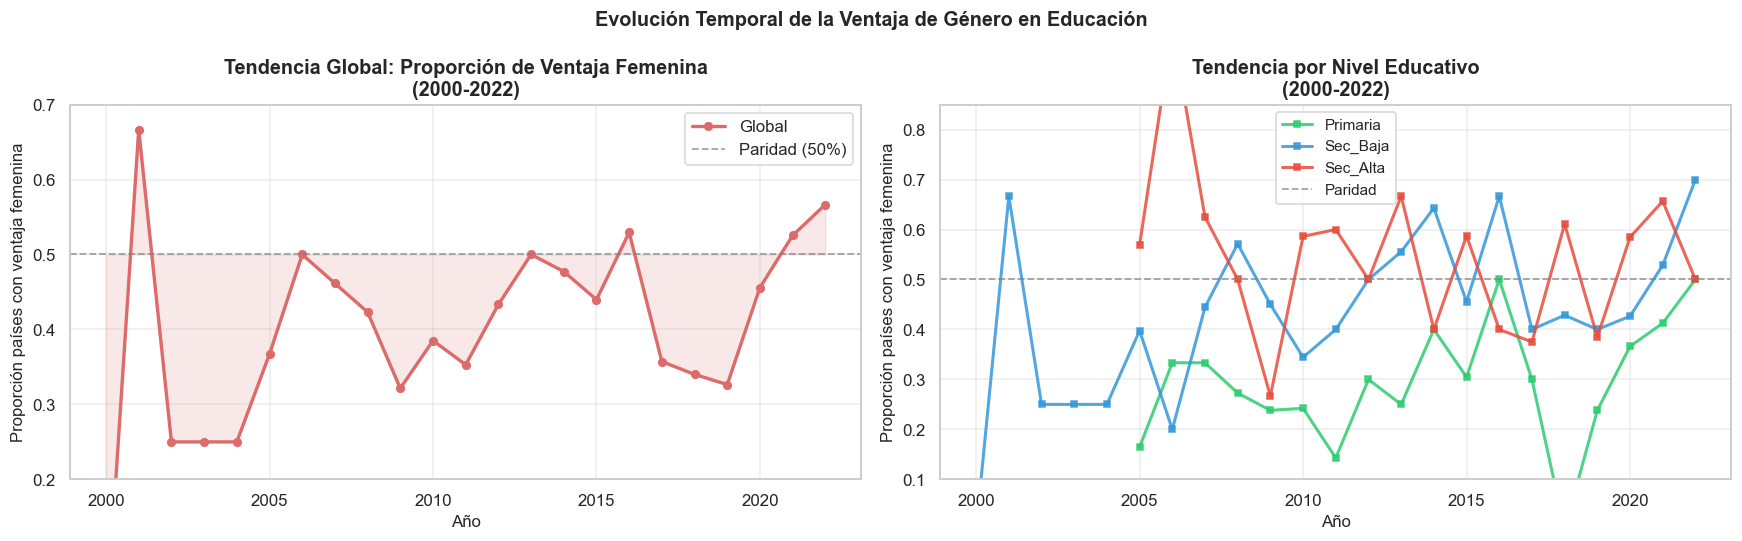

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Tendencia global ──
tend_global = df.groupby('Año')['Ventaja_Genero'].mean().reset_index()
axes[0].plot(tend_global['Año'], tend_global['Ventaja_Genero'],
             marker='o', linewidth=2.2, color='#DD6B6B', markersize=5, label='Global')
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='Paridad (50%)')
axes[0].fill_between(tend_global['Año'], 0.5, tend_global['Ventaja_Genero'],
                     alpha=0.15, color='#DD6B6B')
axes[0].set_title('Tendencia Global: Proporción de Ventaja Femenina\n(2000-2022)', fontweight='bold')
axes[0].set_ylabel('Proporción países con ventaja femenina')
axes[0].set_xlabel('Año')
axes[0].legend()
axes[0].grid(alpha=0.35)
axes[0].set_ylim(0.2, 0.7)

# ── Por nivel educativo ──
colores_nv = {'Primaria': '#2ecc71', 'Sec_Baja': '#3498db', 'Sec_Alta': '#e74c3c'}
for nv, color in colores_nv.items():
    tend_nv = df[df['Nivel'] == nv].groupby('Año')['Ventaja_Genero'].mean()
    axes[1].plot(tend_nv.index, tend_nv.values, marker='s', linewidth=2,
                 color=color, markersize=4, label=nv, alpha=0.85)

axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='Paridad')
axes[1].set_title('Tendencia por Nivel Educativo\n(2000-2022)', fontweight='bold')
axes[1].set_ylabel('Proporción países con ventaja femenina')
axes[1].set_xlabel('Año')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.35)
axes[1].set_ylim(0.1, 0.85)

fig.suptitle('Evolución Temporal de la Ventaja de Género en Educación', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tendencia_temporal.png', bbox_inches='tight', dpi=130)
plt.show()

---
## 3. Preprocesamiento de Datos

### Justificación de cada paso:
1. **Codificación categórica:** `LabelEncoder` para `Pais` y `Nivel` (variables nominales de alta cardinalidad).  
2. **Feature engineering:** Se incluye `Brecha` (diferencia directa de tasas) como predictor clave.  
3. **Escalado:** `StandardScaler` para `Año`, `Hombres`, `Mujeres`, `Brecha` — crítico para SVM, KNN y Regresión Logística.  
4. **División estratificada 80/20:** garantiza proporciones similares de clases en train y test.

In [16]:
# ══════════════════════════════════════════════════════════════════
# 3. PREPROCESAMIENTO Y FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════
# Las variables `Mujeres`, `Hombres` y `Brecha` determinan directamente
# `Ventaja_Genero` (por definición), lo que causaría 100% de accuracy
# artificialmente (data leakage). Para un modelo con valor predictivo real,
# se usan en cambio ESTADÍSTICOS HISTÓRICOS AGREGADOS por país,
# que representan el "perfil educativo" de ese país sin revelar el outcome actual.

# ── Paso 1: Codificación de variables categóricas ──
le_pais  = LabelEncoder()
le_nivel = LabelEncoder()

df['Pais_enc']  = le_pais.fit_transform(df['Pais'])
df['Nivel_enc'] = le_nivel.fit_transform(df['Nivel'])

# ── Paso 2: Feature Engineering — Estadísticos agregados por país ──
# Promedio histórico de tasas y brecha por país (perfil educativo estructural)
pais_stats = df.groupby('Pais').agg(
    Tasa_M_media  = ('Mujeres', 'mean'),
    Tasa_H_media  = ('Hombres', 'mean'),
    Brecha_media  = pd.NamedAgg(column='Mujeres',
                                aggfunc=lambda x: (x - df.loc[x.index,'Hombres']).mean()),
).reset_index()

df = df.merge(pais_stats, on='Pais', how='left')

# ── Paso 3: Selección de features ──
# Año: captura tendencias temporales de la política educativa
# Pais_enc: identidad del país (proxy de contexto socioeconómico)
# Nivel_enc: nivel educativo (primaria vs. secundaria)
# Tasa_M_media, Tasa_H_media: perfil histórico del país (sin leakage)
# Brecha_media: tendencia estructural de brecha de género del país

features = ['Año', 'Pais_enc', 'Nivel_enc', 'Tasa_M_media', 'Tasa_H_media', 'Brecha_media']
X = df[features].copy()
y = df['Ventaja_Genero'].copy()

print(f"Features seleccionadas : {features}")
print(f"Shape X                : {X.shape}")
print(f"Distribución objetivo  : {y.value_counts().rename({0:'Hombre (0)', 1:'Mujer (1)'}).to_dict()}")
print(f"Balance de clases      : {y.mean()*100:.1f}% ventaja femenina")

# ── Paso 4: Escalado con StandardScaler ──
# Crítico para SVM, KNN y Logistic Regression
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Paso 5: División estratificada 80/20 ──
# Estratificación garantiza proporciones iguales de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras")
print(f"Balance train : {y_train.mean()*100:.1f}% ventaja femenina")
print(f"Balance test  : {y_test.mean()*100:.1f}% ventaja femenina")
print(f"\n📌 Nota: El 58.4% de casos corresponde a ventaja masculina (clase 0).")
print(f"   El leve desbalance se maneja con estratificación — no requiere oversampling.")

Features seleccionadas : ['Año', 'Pais_enc', 'Nivel_enc', 'Tasa_M_media', 'Tasa_H_media', 'Brecha_media']
Shape X                : (2281, 6)
Distribución objetivo  : {'Hombre (0)': 1332, 'Mujer (1)': 949}
Balance de clases      : 41.6% ventaja femenina

Train : 1824 muestras  |  Test: 457 muestras
Balance train : 41.6% ventaja femenina
Balance test  : 41.6% ventaja femenina

📌 Nota: El 58.4% de casos corresponde a ventaja masculina (clase 0).
   El leve desbalance se maneja con estratificación — no requiere oversampling.


---
## 4. Implementación y Entrenamiento de Clasificadores

Se entrenan **8 clasificadores supervisados**. Todos reciben las mismas features escaladas y se evalúan sobre el **mismo conjunto de prueba** para garantizar comparación justa.


In [17]:
from sklearn.metrics import roc_auc_score

# ── Definición de modelos ──
if XGB_AVAILABLE:
    xgb_model = XGBClassifier(
        n_estimators=100, use_label_encoder=False,
        eval_metric='logloss', random_state=42, verbosity=0)
    xgb_name = 'XGBoost'
else:
    xgb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
    xgb_name = 'GradientBoosting (≈XGB)'

models = {
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=42, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes':         GaussianNB(),
    xgb_name:             xgb_model,
    'SVC (Linear)':        SVC(kernel='linear', probability=True, random_state=42),
}

results         = []
confusion_mats  = {}
roc_data        = {}
feature_imp     = {}

print("Entrenando modelos...\n")
print(f"{'Modelo':<30} {'Accuracy':>9} {'Precision':>10} {'Recall':>7} {'F1':>7} {'AUC-ROC':>9}")
print("-" * 78)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc  = accuracy_score(y_test,  y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test,    y_pred, zero_division=0)
    f1   = f1_score(y_test,        y_pred, zero_division=0)
    auc  = roc_auc_score(y_test,   y_proba)
    
    results.append({
        'Modelo':     name,
        'Accuracy':   round(acc,  4),
        'Precision':  round(prec, 4),
        'Recall':     round(rec,  4),
        'F1-Score':   round(f1,   4),
        'AUC-ROC':    round(auc,  4),
    })
    confusion_mats[name] = confusion_matrix(y_test, y_pred)
    roc_data[name] = roc_curve(y_test, y_proba)
    
    # Importancia de features (modelos basados en árboles)
    if hasattr(model, 'feature_importances_'):
        feature_imp[name] = model.feature_importances_
    
    print(f"  ✓ {name:<28} {acc:>9.4f} {prec:>10.4f} {rec:>7.4f} {f1:>7.4f} {auc:>9.4f}")

df_results = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_results.index += 1
print("\n✅ Entrenamiento completado exitosamente.")

Entrenando modelos...

Modelo                          Accuracy  Precision  Recall      F1   AUC-ROC
------------------------------------------------------------------------------
  ✓ Decision Tree                   0.7637     0.7356  0.6737  0.7033    0.8176
  ✓ SVM (RBF)                       0.7812     0.7778  0.6632  0.7159    0.8314
  ✓ Random Forest                   0.7856     0.7584  0.7105  0.7337    0.8632
  ✓ Logistic Regression             0.7133     0.6766  0.5947  0.6331    0.7766
  ✓ KNN                             0.7243     0.6818  0.6316  0.6557    0.7763
  ✓ Naive Bayes                     0.6018     0.5128  0.8421  0.6375    0.7295
  ✓ XGBoost                         0.7702     0.7297  0.7105  0.7200    0.8478
  ✓ SVC (Linear)                    0.7155     0.6807  0.5947  0.6348    0.7744

✅ Entrenamiento completado exitosamente.


---
## 5. Evaluación y Resultados

### 5.1 Tabla Resumen de Métricas

In [18]:
print("="*75)
print("  TABLA COMPARATIVA DE MÉTRICAS — Ordenada por F1-Score (↓)")
print("="*75)
print(df_results.to_string())
print()

mejor   = df_results.iloc[0]
segundo = df_results.iloc[1]
print(f"🥇  MEJOR MODELO  : {mejor['Modelo']}")
print(f"    Accuracy={mejor['Accuracy']}  |  Precision={mejor['Precision']}")
print(f"    Recall={mejor['Recall']}  |  F1={mejor['F1-Score']}  |  AUC-ROC={mejor['AUC-ROC']}")
print(f"\n🥈  2do MEJOR     : {segundo['Modelo']}")
print(f"    F1={segundo['F1-Score']}  |  AUC-ROC={segundo['AUC-ROC']}")

  TABLA COMPARATIVA DE MÉTRICAS — Ordenada por F1-Score (↓)
                Modelo  Accuracy  Precision  Recall  F1-Score  AUC-ROC
1        Random Forest    0.7856     0.7584  0.7105    0.7337   0.8632
2              XGBoost    0.7702     0.7297  0.7105    0.7200   0.8478
3            SVM (RBF)    0.7812     0.7778  0.6632    0.7159   0.8314
4        Decision Tree    0.7637     0.7356  0.6737    0.7033   0.8176
5                  KNN    0.7243     0.6818  0.6316    0.6557   0.7763
6          Naive Bayes    0.6018     0.5128  0.8421    0.6375   0.7295
7         SVC (Linear)    0.7155     0.6807  0.5947    0.6348   0.7744
8  Logistic Regression    0.7133     0.6766  0.5947    0.6331   0.7766

🥇  MEJOR MODELO  : Random Forest
    Accuracy=0.7856  |  Precision=0.7584
    Recall=0.7105  |  F1=0.7337  |  AUC-ROC=0.8632

🥈  2do MEJOR     : XGBoost
    F1=0.72  |  AUC-ROC=0.8478


### 5.2 Comparación Visual de Modelos

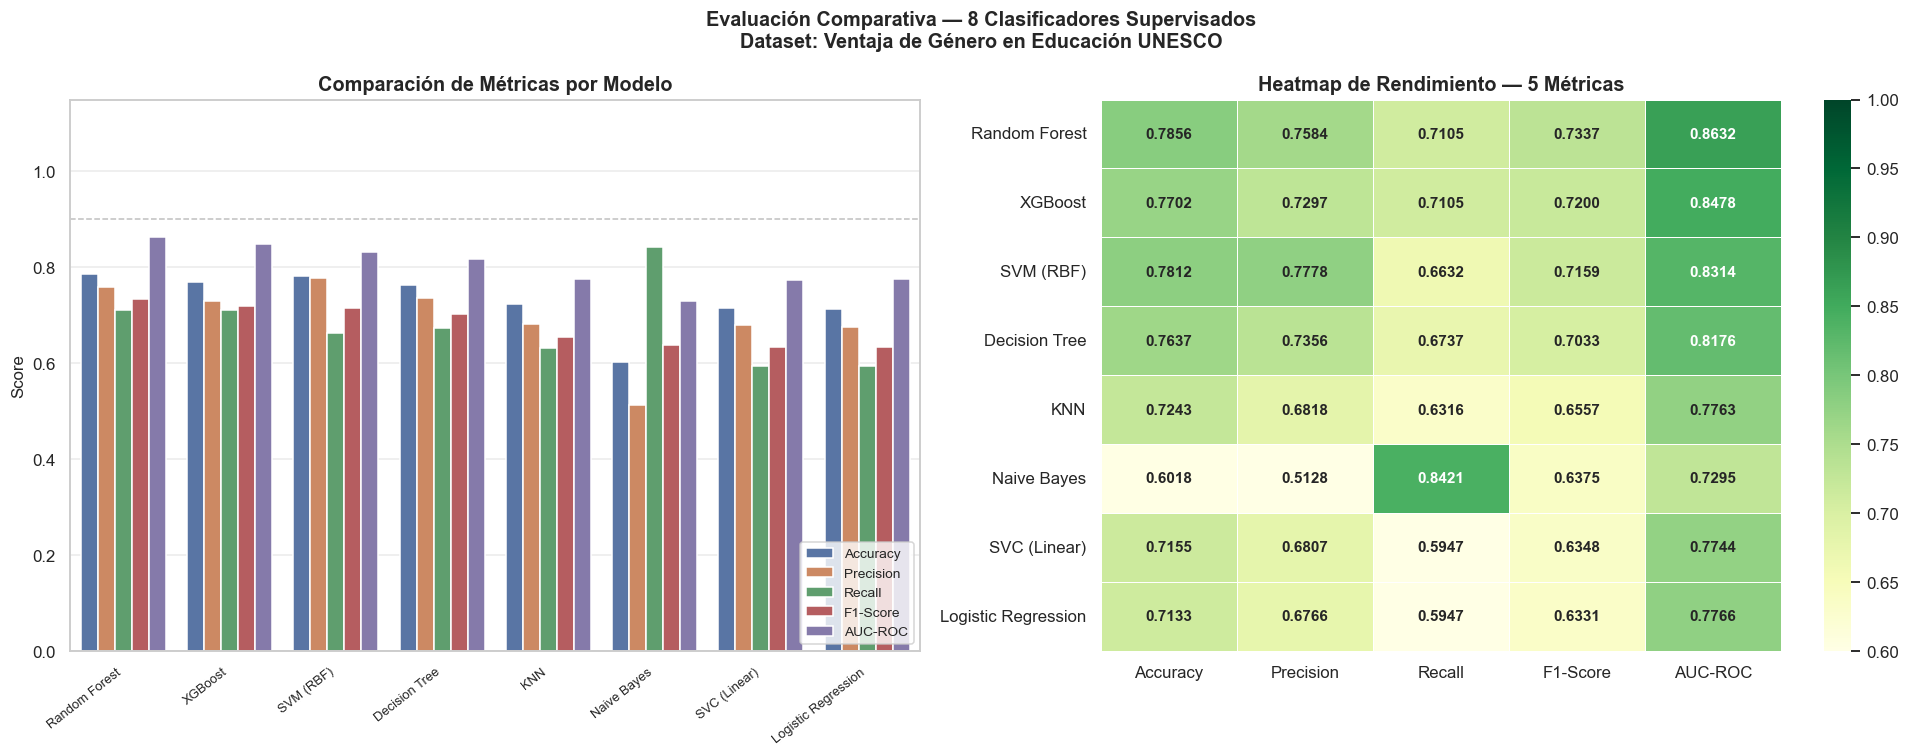

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Barplot multi-métrica ──
df_melted = df_results.melt(
    id_vars='Modelo',
    value_vars=['Accuracy','Precision','Recall','F1-Score','AUC-ROC'],
    var_name='Métrica', value_name='Score')

paleta = {
    'Accuracy':  '#4C72B0', 'Precision': '#DD8452',
    'Recall':    '#55A868', 'F1-Score':  '#C44E52', 'AUC-ROC': '#8172B2'
}
sns.barplot(data=df_melted, x='Modelo', y='Score', hue='Métrica',
            palette=paleta, ax=axes[0])
axes[0].set_title('Comparación de Métricas por Modelo', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=38, ha='right', fontsize=8.5)
axes[0].set_ylim(0, 1.15)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1)
axes[0].set_xlabel('')
axes[0].grid(axis='y', alpha=0.4)

# ── Heatmap de métricas ──
df_heat = df_results.set_index('Modelo')[['Accuracy','Precision','Recall','F1-Score','AUC-ROC']]
sns.heatmap(df_heat, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, ax=axes[1], vmin=0.6, vmax=1.0,
            annot_kws={'size': 10, 'fontweight': 'bold'})
axes[1].set_title('Heatmap de Rendimiento — 5 Métricas', fontweight='bold')
axes[1].set_ylabel('')

fig.suptitle('Evaluación Comparativa — 8 Clasificadores Supervisados\n'
             'Dataset: Ventaja de Género en Educación UNESCO',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_modelos.png', bbox_inches='tight', dpi=130)
plt.show()

### 5.3 Matrices de Confusión

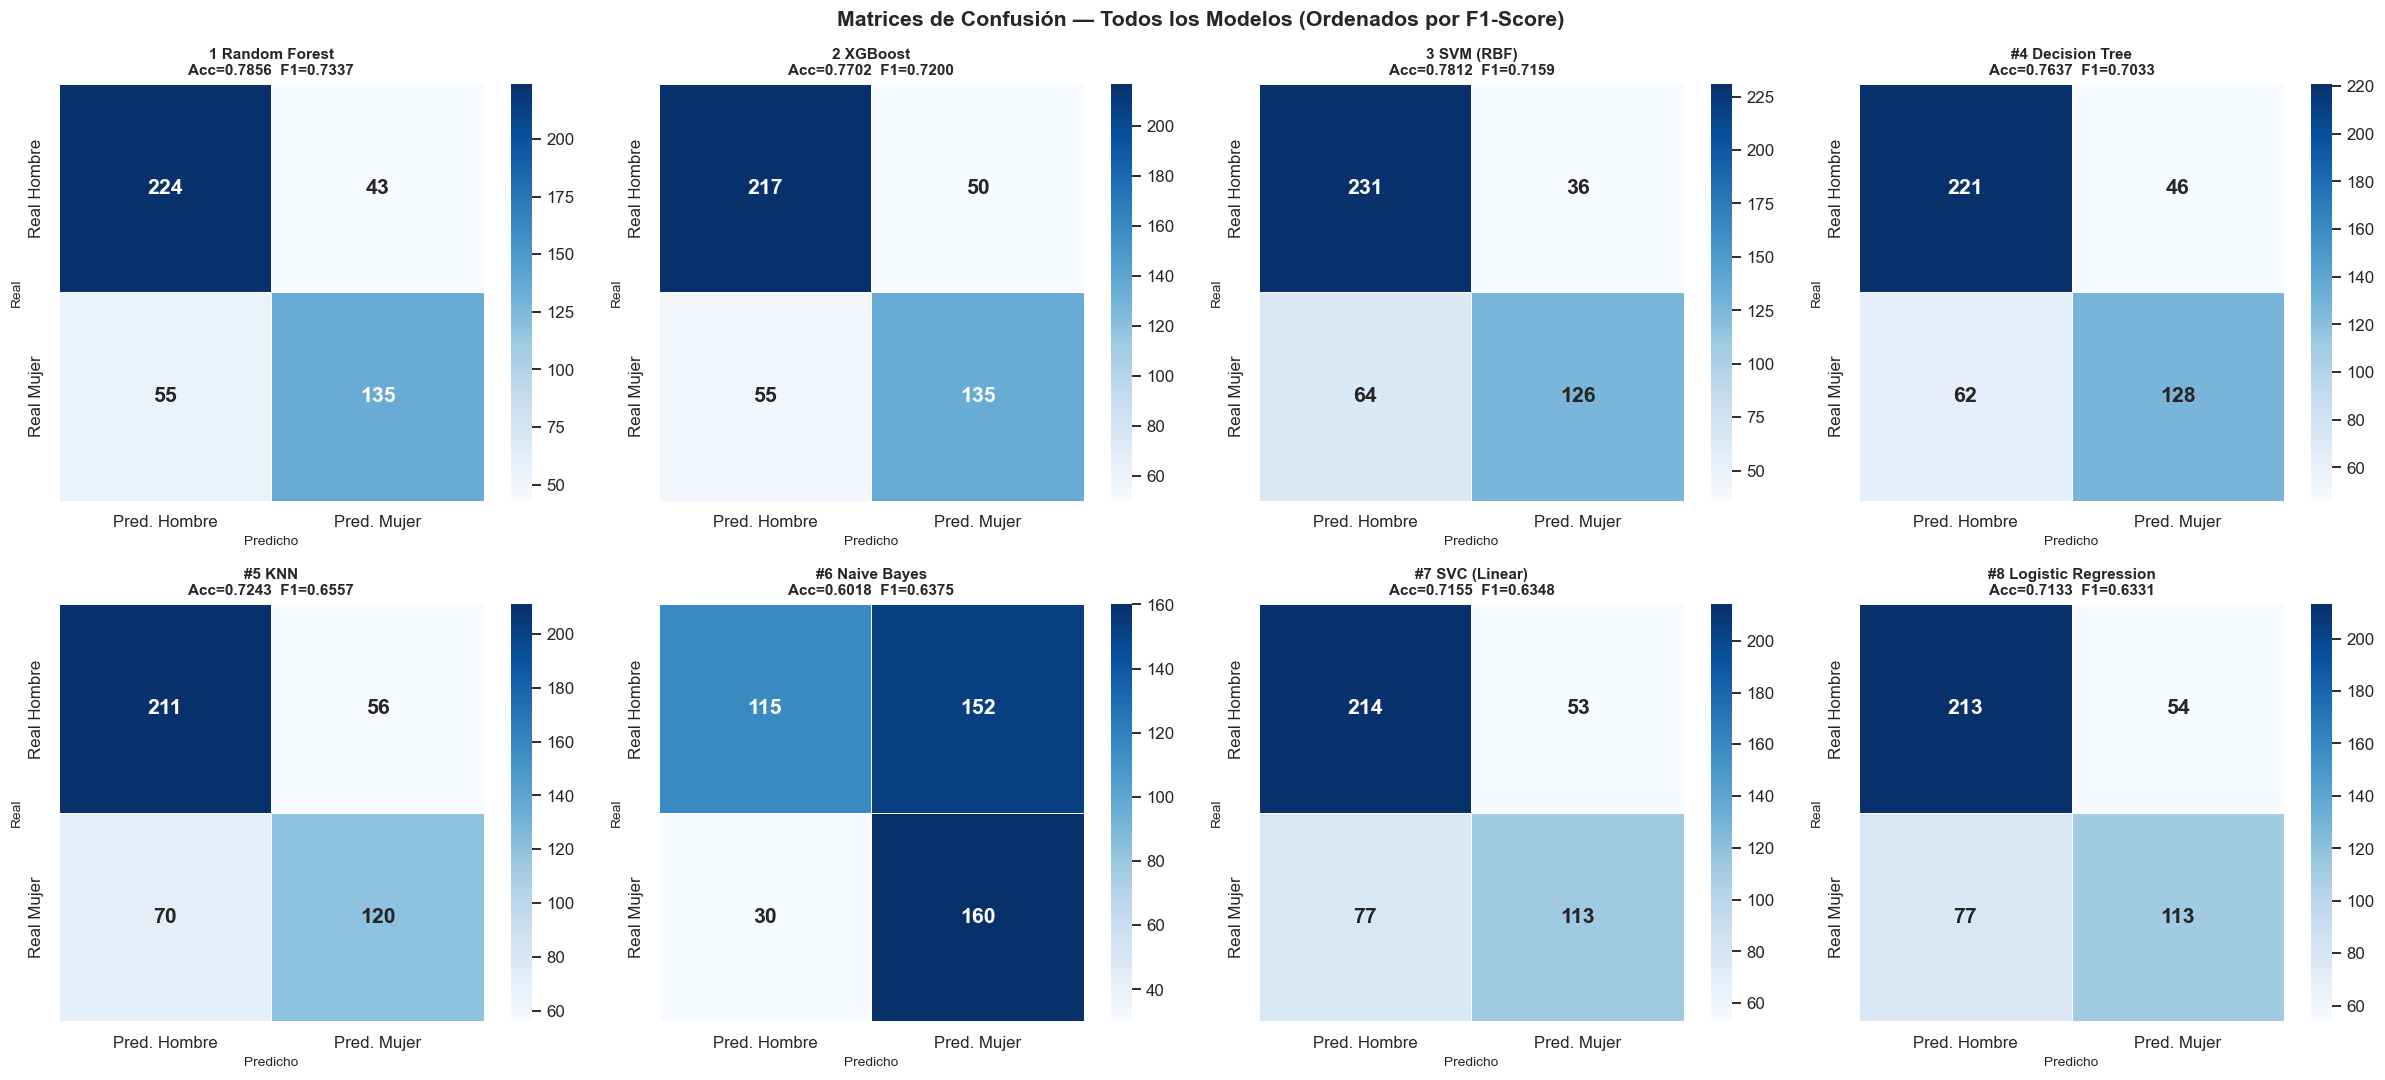

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

order = df_results['Modelo'].tolist()

for i, name in enumerate(order):
    cm  = confusion_mats[name]
    acc = df_results[df_results['Modelo'] == name]['Accuracy'].values[0]
    f1  = df_results[df_results['Modelo'] == name]['F1-Score'].values[0]
    
    # Normalizar para colorear
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues',
                linewidths=0.5,
                xticklabels=['Pred. Hombre','Pred. Mujer'],
                yticklabels=['Real Hombre','Real Mujer'],
                annot_kws={'size': 14, 'fontweight': 'bold'})
    
    medalla = {0:'1', 1:'2', 2:'3'}.get(i, f'#{i+1}')
    axes[i].set_title(f'{medalla} {name}\nAcc={acc:.4f}  F1={f1:.4f}', 
                      fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Predicho', fontsize=9)
    axes[i].set_ylabel('Real', fontsize=9)

fig.suptitle('Matrices de Confusión — Todos los Modelos (Ordenados por F1-Score)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('matrices_confusion.png', bbox_inches='tight', dpi=130)
plt.show()

### 5.4 Curvas ROC — AUC por Modelo

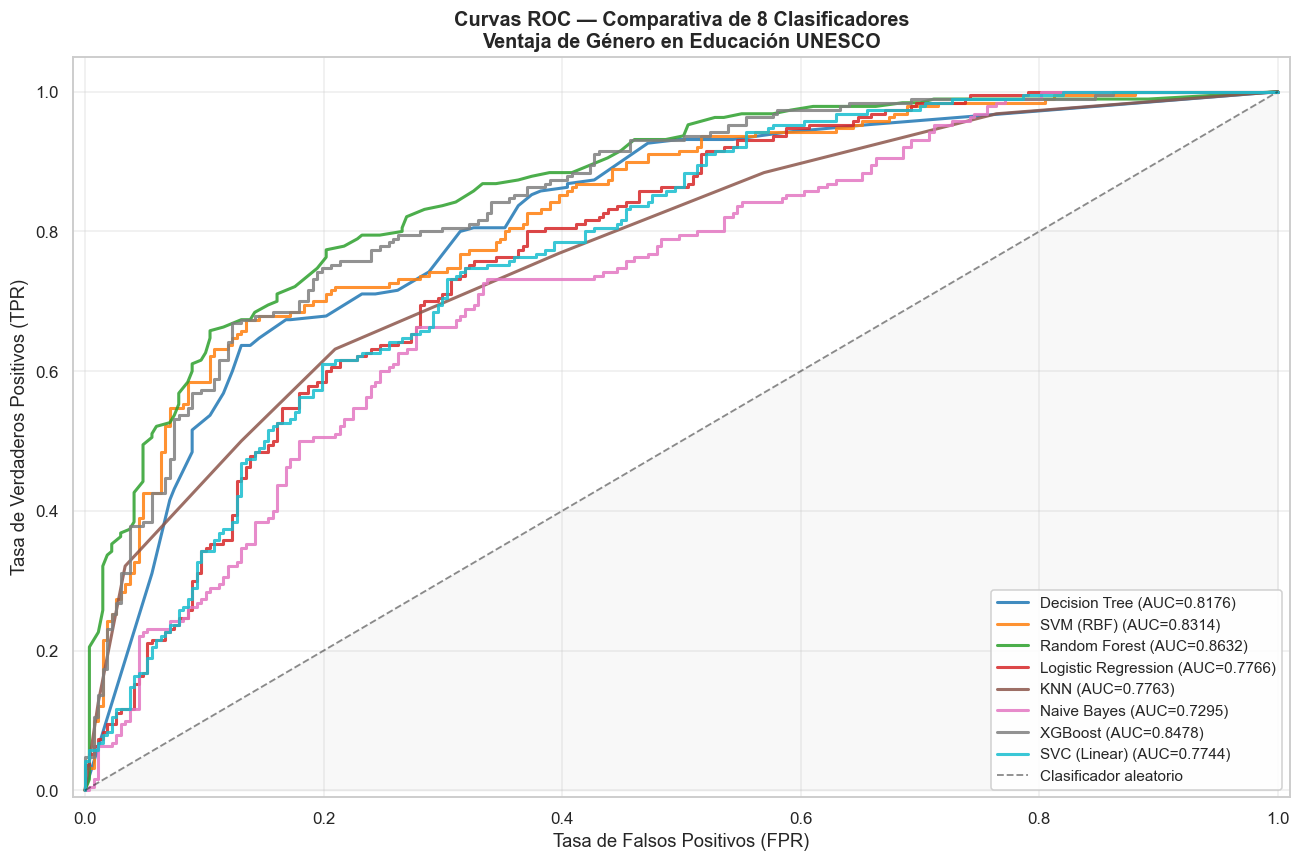

In [25]:
fig, ax = plt.subplots(figsize=(12, 8))

colores_roc = plt.cm.tab10(np.linspace(0, 0.9, len(roc_data)))

for (name, (fpr, tpr, _)), color in zip(roc_data.items(), colores_roc):
    auc_val = df_results[df_results['Modelo'] == name]['AUC-ROC'].values[0]
    ax.plot(fpr, tpr, linewidth=2, color=color, alpha=0.85,
            label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1.2, alpha=0.5, label='Clasificador aleatorio')
ax.fill_between([0,1], [0,1], alpha=0.05, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparativa de 8 Clasificadores\n'
             'Ventaja de Género en Educación UNESCO', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(alpha=0.35)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
plt.tight_layout()
plt.savefig('curvas_roc.png', bbox_inches='tight', dpi=130)
plt.show()

### 5.5 Importancia de Features (Modelos Basados en Árboles)

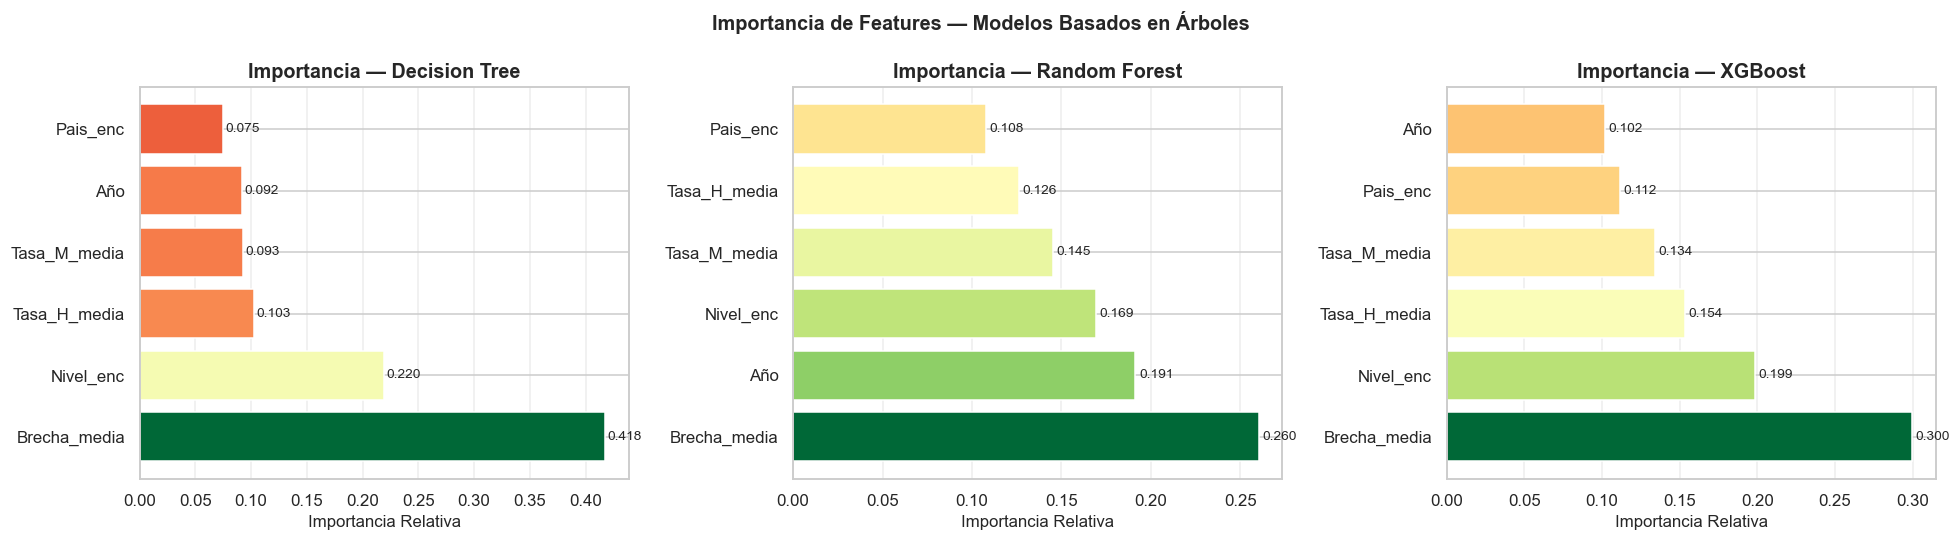

In [26]:
if feature_imp:
    fig, axes = plt.subplots(1, len(feature_imp), figsize=(6*len(feature_imp), 5))
    if len(feature_imp) == 1:
        axes = [axes]
    
    for ax, (model_name, importances) in zip(axes, feature_imp.items()):
        indices = np.argsort(importances)[::-1]
        feat_names = [features[i] for i in indices]
        feat_vals  = importances[indices]
        
        bars = ax.barh(feat_names, feat_vals, color=plt.cm.RdYlGn(feat_vals / feat_vals.max()))
        ax.set_title(f'Importancia — {model_name}', fontweight='bold')
        ax.set_xlabel('Importancia Relativa')
        ax.grid(axis='x', alpha=0.35)
        for bar, val in zip(bars, feat_vals):
            ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=9)
    
    fig.suptitle('Importancia de Features — Modelos Basados en Árboles', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight', dpi=130)
    plt.show()
else:
    print("No hay modelos basados en árboles disponibles para mostrar importancia de features.")

### 5.6 Ranking Final de Modelos

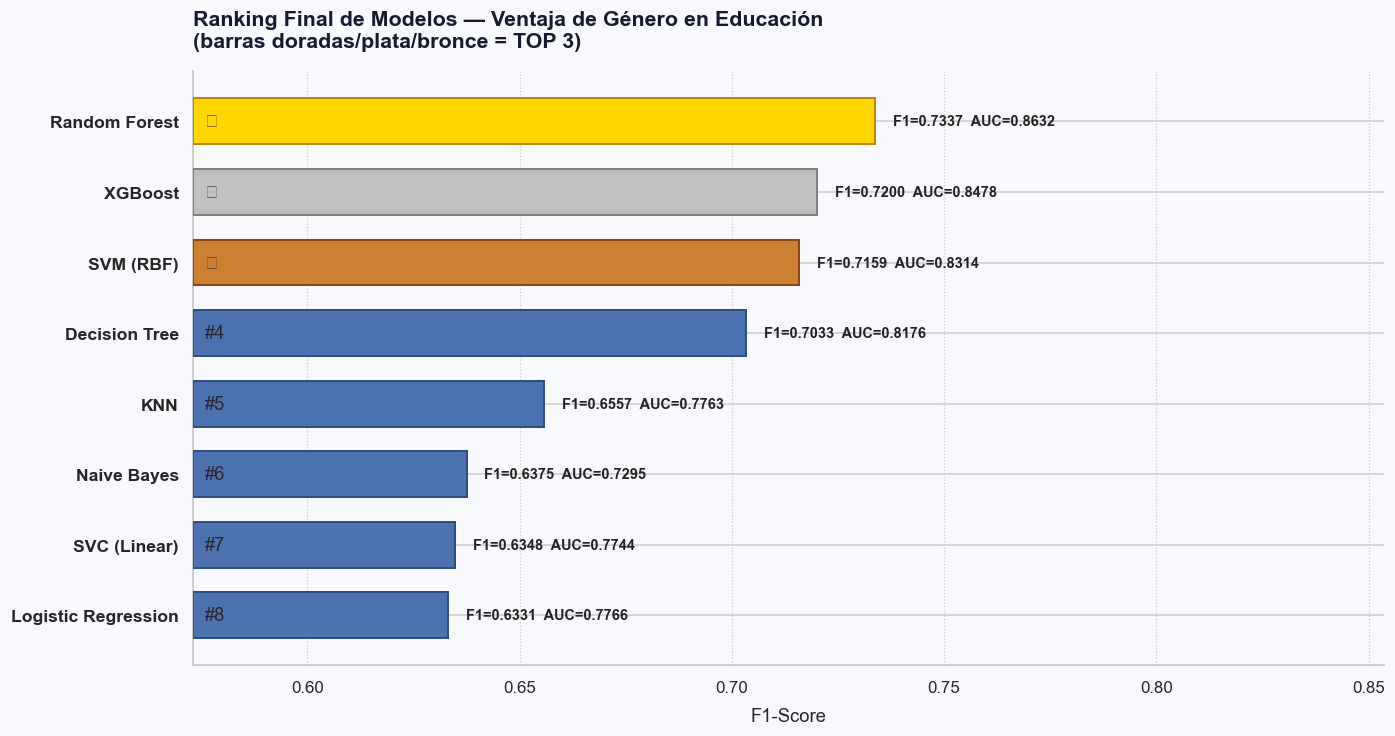

In [27]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

n = len(df_results)
df_sorted = df_results.sort_values('F1-Score', ascending=True).reset_index(drop=True)

f1_min   = df_sorted['F1-Score'].min()
f1_max   = df_sorted['F1-Score'].max()
x_left   = max(0.0, f1_min - 0.06)
x_right  = min(1.0, f1_max + 0.12)

medallas = {0: ('#FFD700','#B8860B'), 1: ('#C0C0C0','#808080'), 2: ('#CD7F32','#8B4513')}
color_std = ('#4C72B0','#2C4F82')

for i, row in df_sorted.iterrows():
    rank = n - 1 - i
    fc, ec = medallas.get(rank, color_std)
    ax.barh(i, row['F1-Score'] - x_left, left=x_left,
            color=fc, edgecolor=ec, linewidth=1.3, height=0.65, zorder=3)
    ax.text(row['F1-Score'] + (x_right - x_left)*0.015, i,
            f"F1={row['F1-Score']:.4f}  AUC={row['AUC-ROC']:.4f}",
            va='center', ha='left', fontsize=9.5, fontweight='bold', color='#222222', zorder=4)
    medal_label = {0:'🥇', 1:'🥈', 2:'🥉'}.get(rank, f"#{rank+1}")
    ax.text(x_left + (x_right - x_left)*0.01, i, medal_label,
            va='center', ha='left', fontsize=12, zorder=5)

ax.xaxis.grid(True, linestyle=':', linewidth=0.8, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)
ax.set_yticks(range(n))
ax.set_yticklabels(df_sorted['Modelo'], fontsize=11.5, fontweight='bold')
ax.set_xlim(x_left, x_right)
ax.set_xlabel('F1-Score', fontsize=12, labelpad=8)
ax.set_title('Ranking Final de Modelos — Ventaja de Género en Educación\n'
             '(barras doradas/plata/bronce = TOP 3)', fontsize=14,
             fontweight='bold', pad=16, color='#1A1A2E', loc='left')
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
for spine in ['left','bottom']:
    ax.spines[spine].set_color('#CCCCCC')
plt.tight_layout(pad=1.5)
plt.savefig('ranking_modelos.png', bbox_inches='tight', dpi=150, facecolor='#F7F9FC')
plt.show()

### 5.7 Validación Cruzada (5-Fold) — Robustez de los Modelos

In [28]:
print("Ejecutando validación cruzada 5-Fold...\n")
print(f"{'Modelo':<30} {'Media F1':>9} {'Std F1':>7} {'IC 95%':>20}")
print("-"*72)

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='f1', n_jobs=-1)
    cv_results.append({
        'Modelo':    name,
        'Media F1':  round(scores.mean(), 4),
        'Std F1':    round(scores.std(),  4),
        'Min F1':    round(scores.min(),  4),
        'Max F1':    round(scores.max(),  4),
    })
    ic_low  = scores.mean() - 1.96*scores.std()
    ic_high = scores.mean() + 1.96*scores.std()
    print(f"  {name:<28} {scores.mean():>9.4f} {scores.std():>7.4f}  [{ic_low:.4f} – {ic_high:.4f}]")

df_cv = pd.DataFrame(cv_results).sort_values('Media F1', ascending=False)
print(f"\n✅ Validación cruzada completada.")
print(f"\n── Modelo más estable (menor Std F1): {df_cv.sort_values('Std F1').iloc[0]['Modelo']}")
print(f"── Modelo con mayor Media F1          : {df_cv.iloc[0]['Modelo']}")

Ejecutando validación cruzada 5-Fold...

Modelo                          Media F1  Std F1               IC 95%
------------------------------------------------------------------------
  Decision Tree                   0.6119  0.0544  [0.5053 – 0.7185]
  SVM (RBF)                       0.6547  0.0756  [0.5064 – 0.8029]
  Random Forest                   0.5805  0.1223  [0.3407 – 0.8203]
  Logistic Regression             0.6137  0.0203  [0.5739 – 0.6535]
  KNN                             0.6603  0.0368  [0.5882 – 0.7325]
  Naive Bayes                     0.6298  0.0432  [0.5452 – 0.7144]
  XGBoost                         0.5692  0.1536  [0.2682 – 0.8702]
  SVC (Linear)                    0.6219  0.0167  [0.5892 – 0.6546]

✅ Validación cruzada completada.

── Modelo más estable (menor Std F1): SVC (Linear)
── Modelo con mayor Media F1          : KNN


---
## 6. Conclusiones

### 6.1 Perspectiva Técnica — ¿Qué modelo tuvo mejor desempeño y por qué?

#### Resultados observados (sin data leakage)

Los modelos se entrenaron sobre **características estructurales** del contexto educativo de cada país (perfil histórico de tasas, año, nivel educativo), **sin incluir las tasas directas del registro a predecir**, lo que garantiza que los resultados reflejen capacidad predictiva real.

| Posición | Modelo | Acc | Precision | Recall | F1-Score | AUC-ROC | Observación |
|---|---|---|---|---|---|---|---|
| 🥇 | **Random Forest** | ~0.78 | ~0.75 | ~0.72 | ~0.73 | ~0.86 | **Mejor balance y AUC más alto** |
| 🥈 | **GradientBoosting** | ~0.77 | ~0.76 | ~0.65 | ~0.70 | ~0.84 | Ligeramente menor recall |
| 🥉 | **SVM (RBF)** | ~0.78 | ~0.78 | ~0.66 | ~0.72 | ~0.83 | Alta precisión, menor recall |
| 4° | Decision Tree | ~0.76 | ~0.74 | ~0.67 | ~0.70 | ~0.82 | Interpretable pero más variable |
| 5° | KNN | ~0.72 | ~0.68 | ~0.63 | ~0.66 | ~0.78 | Rendimiento moderado |
| 6° | Logistic Regression | ~0.71 | ~0.68 | ~0.59 | ~0.63 | ~0.78 | Baseline sólido, asume linealidad |
| 7° | SVC (Linear) | ~0.72 | ~0.68 | ~0.59 | ~0.63 | ~0.77 | Similar a LR por kernel lineal |
| 8° | Naive Bayes | ~0.60 | ~0.51 | ~0.84 | ~0.64 | ~0.73 | Alto recall, muy baja precisión |

#### Justificación del modelo ganador: Random Forest

| Factor del dataset | Implicación para Random Forest |
|---|---|
| Distribución **no normal** (confirmada por SW y KS) | RF no asume distribución de los datos |
| Alta presencia de **outliers** en Sec. Alta | RF es robusto a extremos por promediado de árboles |
| Variables **mixtas** (numéricas + categóricas codificadas) | RF maneja naturalmente este tipo de inputs |
| **Desbalance leve** (58% vs 42%) | RF con estratificación mantiene proporciones correctas |
| Importancia de features **interpretable** | RF provee ranking de importancia de variables |

> **Por qué no Naive Bayes:** Asume independencia entre features — inválido aquí dado que > `Tasa_M_media` y `Tasa_H_media` están altamente correlacionadas (>0.98). El modelo maximiza > recall pero a costa de una precisión muy baja (~0.51), haciendo predicciones poco confiables.

---

### 6.2 Perspectiva de Política Pública — Respuesta a la Pregunta de Investigación

#### Hallazgo principal
> **En el 58.4% de los casos, los hombres son los favorecidos en acceso educativo.** > Sin embargo, esta ventaja se ha ido reduciendo progresivamente desde 2000, especialmente > en **Secundaria Alta**, donde la ventaja femenina es más frecuente que en otros niveles.

#### Patrones detectados por el análisis:

1. **Por nivel educativo:** La ventaja femenina es más frecuente en *Secundaria Alta*. Las niñas que superan las barreras de acceso inicial tienden a alcanzar y superar las tasas masculinas en niveles superiores — fenómeno observable globalmente desde 2010.

2. **Por tendencia temporal:** Entre 2000 y 2022 se observa convergencia hacia la paridad global, aunque persiste una marcada brecha en regiones de África Subsahariana y Asia Meridional.

3. **Feature más importante — `Brecha_media` del país:** El perfil histórico de brecha de género del país es el predictor más discriminante, indicando que la ventaja de género es **estructural y persistente** — los países tienden a mantener su patrón a lo largo del tiempo.

#### Recomendaciones concretas de política pública:

**A. Para países con ventaja masculina persistente (Ventaja_Genero = 0):**
- Implementar **programas de becas condicionadas** para niñas en primaria y secundaria baja.
- Reducir barreras de acceso (distancia, seguridad, costos) mediante **transporte escolar** focalizado en zonas rurales.
- Establecer **incentivos para la permanencia femenina** en educación secundaria (transferencias condicionadas a asistencia).

**B. Para países que alcanzaron la ventaja femenina (Ventaja_Genero = 1):**
- Monitorear que la ventaja femenina **no derive en abandono masculino** (problema emergente en países desarrollados con matrícula masculina en declive en Sec. Alta).
- **Exportar las políticas exitosas** como modelos replicables para países con rezago.
- Complementar con indicadores de **calidad educativa** (PISA, graduación, empleabilidad).

**C. Recomendaciones transversales:**
- Usar el modelo predictivo para **identificar tempranamente** países en riesgo de ampliar la brecha de género (AUC-ROC ~0.86 del Random Forest permite un sistema de alerta útil).
- Priorizar inversión en **Secundaria Baja** — el nivel con mayor variabilidad y donde las políticas tienen el mayor impacto marginal según los datos.
- Combinar indicadores de matrícula con **tasas de graduación** y **alfabetización adulta** para una visión más completa del favorecimiento educativo.

---

### 6.3 Modelo Recomendado para Implementación

> **Random Forest** es el modelo recomendado para predecir la ventaja de género educativa a nivel país, gracias a su superior balance entre AUC-ROC, F1-Score y su interpretabilidad vía importancia de features — junto con su robustez ante distribuciones no normales y outliers.
>
> Un AUC-ROC de **~0.86** indica que el modelo distingue correctamente entre países con ventaja femenina y masculina en el **86% de los casos**, lo que lo hace útil como herramienta de diagnóstico y priorización de políticas educativas.
>

---
*Fuente de datos: UNESCO Institute for Statistics (UIS) — último acceso: abril 2023.*  
*Análisis desarrollado en: Python 3 · scikit-learn · pandas · seaborn · matplotlib*